In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii
from astropy import units as u
from astropy.table import Table, vstack, hstack
import line_ratios as lr
from scipy.optimize import curve_fit

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../')
# import src.ifu_tools.line_ratios as lr

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()

True

In [4]:
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

In [5]:
test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

In [6]:
def linear(x, *params):
    return params[0]*x+params[1]

In [7]:
tab

object_id,ra,dec,z,angdisp,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
28d07m28pt35s-28d53m18pt439s,28.124541666666662,-28.888455277777776,0.3685089804926993,26.18756698942221,8.257105031271637,0.13499746423602704,8.19876926483537,0.01112376115940017,8.350356506066793,1.7324940505772704,784.2894245181611,262.7340650394521,0.4127,macs0152m28,1510.013640700127,87.899338157534,35.219154485348156,2.0501406651496796,5006.835951321285,2.000851928624639,47.66104780419961,427.1919308063104,136.72975380269563,5.898970866095592,1.8880619600846873,4958.900222500991,1.6770166740703585,39.12405443693391,169.88944496287564,108.48075459608935,2.549205969919668,1.6277632038775045,3726.6665477785414,1.5199258794840265,46.09705344508258,512.8991906061206,146.7531639742823,11.734252437860937,3.35746030344482,3727.7032777640943,4.78487322574087,161.6084808898156,1258.0947535334851,9

Mean HA/HB  is 4.186079877220326 pm 0.19781034899504382
This gives EBV of 0.2698486192258386


True

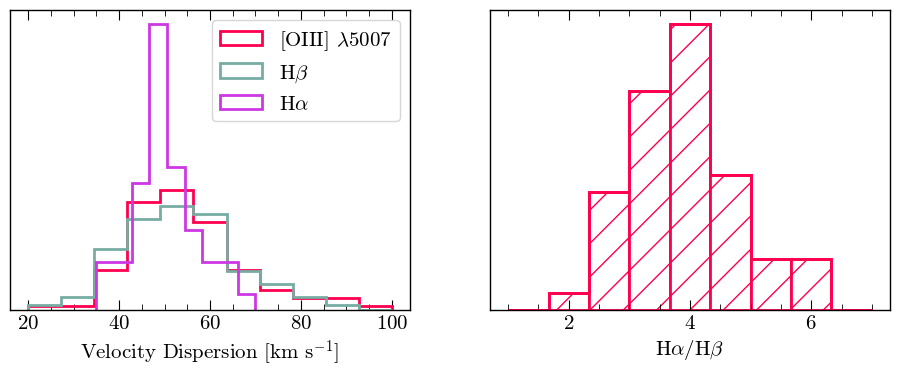

In [8]:
fig, ax = pf.create_plot()
lines = ['oiii5007', 'hbeta', 'halpha']
colors= ['#ff004f', '#77aca2', "#cd37e4"]
bins = 2*[np.linspace(20,100,12)]+[np.linspace(35,70,10)]
for i,l in enumerate(lines):
    ax.hist(tab[l+'_vel_disp'], bins=bins[i], histtype='step', lw=2, label=lambda_keys.get(l), density=True, color=colors[i])
ax.legend()
ax.set_yticks([])
ax.set_xlabel('Velocity Dispersion [km s$^{-1}$]')

ax2 = fig.add_axes((1.2,0,1,1))

hahb = tab['halpha_flux']/tab['hbeta_flux']
mask = np.isfinite(hahb)&(hahb>0)
ax2.hist(hahb[mask],bins=np.linspace(1,7,10), histtype='step', lw=2, density=True, color='#ff004f')
ax2.hist(hahb[mask],bins=np.linspace(1,7,10), lw=2, density=True, edgecolor='#ff004f', hatch="/", facecolor='white')

ax2.set_yticks([])
ax2.set_xlabel(r'H$\alpha$/H$\beta$')

print(f'Mean HA/HB  is {np.mean(hahb[mask])} pm {np.std(hahb[mask])/np.sqrt(len(hahb[mask]))}')
print(f'This gives EBV of {lr.get_ebv(np.mean(hahb[mask]),2.86,6562.80,4861.33)}')

pf.fix_plot([ax,ax2])

True

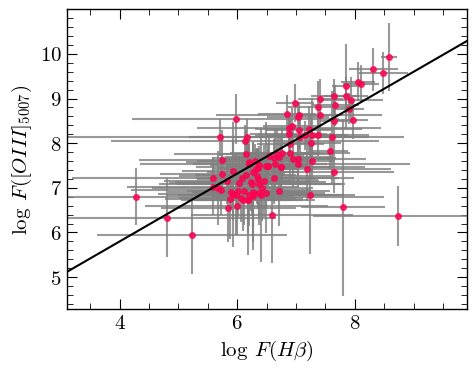

In [9]:
fig, ax = pf.create_plot()

xlims = (3.3,9.7)
xlol = np.log(tab['hbeta_flux'])<xlims[0]
xup = np.log(tab['hbeta_flux'])>xlims[1]

ax.errorbar(np.log(tab['hbeta_flux']),np.log(tab['oiii5007_flux']), 
            fmt='o', color='#ff004f', ms=4,
            xerr= np.abs(((tab['hbeta_flux_err'])/(tab['hbeta_flux']))*np.log(tab['hbeta_flux'])),
            yerr = np.abs((tab['oiii5007_flux_err']/tab['oiii5007_flux'])*np.log(tab['oiii5007_flux'])),
            ecolor='gray', alpha=0.8, xlolims=xlol, xuplims=xup)

ax.set_ylabel(r'$\log\;F([OIII]_{5007})$')
ax.set_xlabel(r'$\log\;F(H\beta)$')

ax.set_xlim(3.1,9.9)

xvals = np.log(tab['hbeta_flux'])
yvals = np.log(tab['oiii5007_flux'])
yerr = np.abs((tab['oiii5007_flux_err']/tab['oiii5007_flux'])*np.log(tab['oiii5007_flux']))

mask = (np.isfinite(xvals))&(np.isfinite(yvals))
popt, cov = curve_fit(linear,xvals[mask], yvals[mask], p0=2*[0], sigma=yerr[mask])
grid = np.linspace(3,10,100)
ax.plot(grid, linear(grid,*popt), color='k',zorder=10)

pf.fix_plot([ax])


In [10]:
yvals[mask]

7.319873963344411
8.521437535069564
7.493489578953355
8.050028439310628
7.273802903477329
8.288315070600383
7.698702865048631
7.504114290864653
7.821407137907455
6.905310605801426
6.830841559961302


True

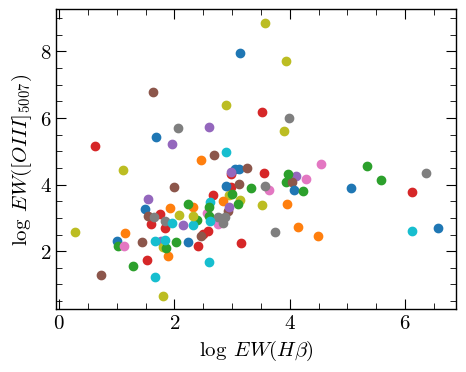

In [11]:
fig, ax = pf.create_plot()

minitab = tab.group_by('name')
for g in minitab.groups:
    ax.scatter(np.log(g['hbeta_ew']),np.log(g['oiii5007_ew']))

ax.set_ylabel(r'$\log\;EW([OIII]_{5007})$')
ax.set_xlabel(r'$\log\;EW(H\beta)$')

pf.fix_plot([ax])

True

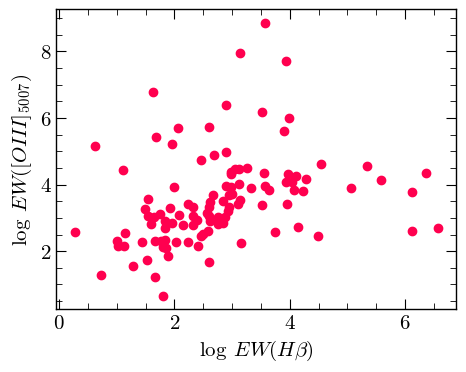

In [12]:
fig, ax = pf.create_plot()
ax.scatter(np.log(tab['hbeta_ew']),np.log(tab['oiii5007_ew']), color='#ff004f')
ax.set_ylabel(r'$\log\;EW([OIII]_{5007})$')
ax.set_xlabel(r'$\log\;EW(H\beta)$')
pf.fix_plot([ax])

True

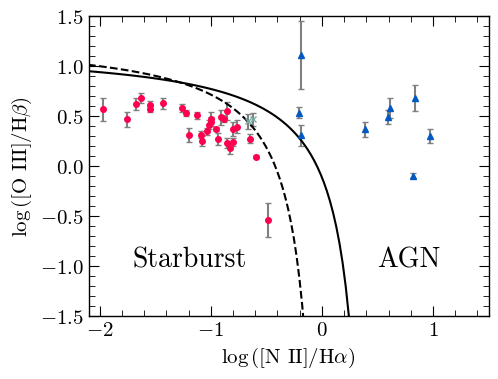

In [13]:
fig, ax = pf.create_plot()
ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(tab['nii6583_flux']/tab['halpha_flux'])
yvals = np.log10(tab['oiii5007_flux']/tab['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (tab['nii6583_flux_err']/tab['nii6583_flux'])**2 + (tab['halpha_flux_err']/tab['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (tab['oiii5007_flux_err']/tab['oiii5007_flux'])**2 + (tab['hbeta_flux_err']/tab['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax])

True

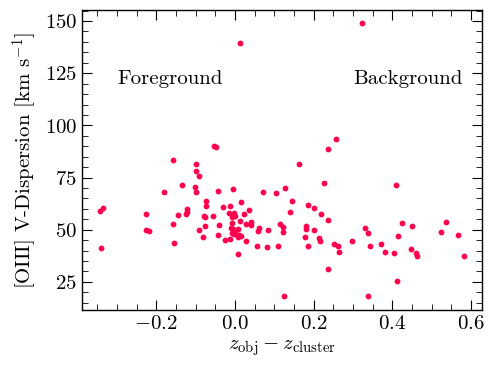

In [14]:
fix, ax = pf.create_plot()

ax.scatter((tab['z']-tab['zcluster']),tab['oiii5007_vel_disp'], color='#ff004f', s=10)
ax.text(-.3,120,'Foreground', fontsize=15)
ax.text(.3,120,'Background', fontsize=15)


ax.set_xlabel(r'$z_{\mathrm{obj}}-z_{\mathrm{cluster}}$')
ax.set_ylabel(r'[OIII] V-Dispersion [km s$^{-1}$]')
pf.fix_plot([ax])

True

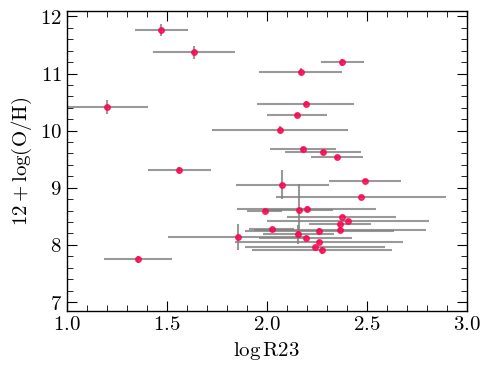

In [15]:
fig, ax = pf.create_plot()

snr = (tab['R23_e']/tab['R23'])
mask = snr<0.2

ax.errorbar(np.log(tab['R23'])[mask],tab['Z_dir'][mask], 
            fmt='o', color='#ff004f', ms=4,
            xerr= np.abs(np.log(tab['R23'])*snr)[mask],
            yerr = tab['Z_dir_e'][mask],
            ecolor='gray', alpha=0.8)

ax.set_xlim(1,3)
ax.set_xlabel(r'$\log$R23')
ax.set_ylabel(r'$12+\log(\mathrm{O/H})$')


pf.fix_plot([ax])

In [ ]:
o23 = (tab['oii3729_flux'])/(tab['oiii5007_flux'])
o23_err = np.log10(o23)*np.sqrt( ((tab['oii3729_flux_err'])/tab['oii3729_flux'])**2 + ((tab['oiii5007_flux_err'])/(tab['oiii5007_flux']))**2)

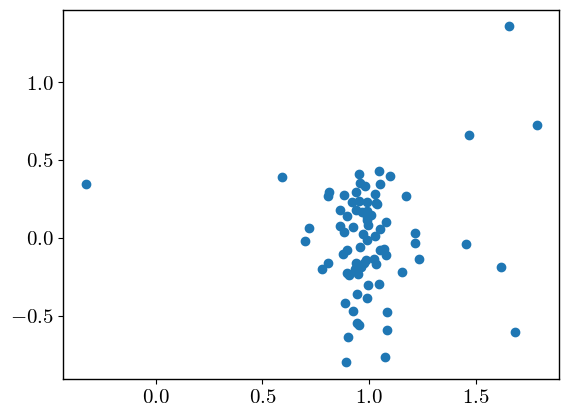

In [23]:
plt.scatter(np.log10(tab['R23']),np.log10(o23))